# Radiative Transfer Modeling with vSmartMOM

---
Last modified: January 17, 2025 (JY)

This notebook uses a modified version of vSmartMOM with functions specifically for isoprene to calculate radiances with different amounts of isoprene/water vapor/aerosols/etc.

This notebook is coded in Julia.

In [1]:
# Activate Julia packages
using Pkg;
using Revise;

Pkg.activate("vSmartMOM_ISOP.jl");
Pkg.instantiate();

# Using local module, since the current version of vSmartMOM does not support isoprene (not a HITRAN line list species)
include("vSmartMOM_ISOP.jl/src/vSmartMOM.jl");

# Imports
using Statistics, PlutoUI, Polynomials, PlotlyBase, Plots, LazyArtifacts, LinearAlgebra, NCDatasets, Format, LaTeXStrings, .vSmartMOM;
include("helper_functions.jl");

default(fontfamily="Helvetica");

  Activating project at `~/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl`
Precompiling project...
  13462.2 ms  ✓ vSmartMOM
  1 dependency successfully precompiled in 15 seconds. 382 already precompiled.
  1 dependency had output during precompilation:
┌ vSmartMOM
│  WARNING: method definition for elemental! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/elemental_canopy.jl:7 declares type variable M but does not use it.
│  WARNING: method definition for interaction_hdrf! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/interaction_hdrf.jl:9 declares type variable FT2 but does not use it.
│  WARNING: method definition for interaction_hdrf_canopy! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/interaction_hdrf.jl:47 declares type variable FT2 but does not use it.
│  WARNING: method definition for interaction_hdrf_canopy! at /Users/jamesyoon/Documents/Radiative_Tra

### We now need to specify parameters for the model.

I have downloaded 10 days (2019-07-01 to 2019-07-10) in the MERRA2 folder. You will need to manually download more days if you would like different conditions.

In [2]:
function retrieve_merra2_conditions(date, startTime, lat, lon)
    # Feel free to change the MERRA2 file and folder paths
    MerraFile = "MERRA2_400.inst6_3d_ana_Nv." * date * ".nc4"
    MerraFolder = "MERRA2/"
    MerraFilePath = joinpath(MerraFolder, MerraFile)

    # These files have 00, 06, 12 or 18 in UTC, i.e. 6 hourly data stacked together
    hour = parse(Int, chop(startTime));
    hour_index = Int(hour / 6);

    # Read atmos profile (from helperfunctions.jl)
    return read_atmos_profile(MerraFilePath, lat, lon, hour_index);
end

# Parameters for atmospheric profile
date = "20190701"
startTime = "06z"
lat = 2.
lon = 100.

merra2_profile = retrieve_merra2_conditions(date, startTime, lat, lon);
pressures = merra2_profile.p_levels / 100; # Convert to hPa
temperatures = merra2_profile.T;
specific_humidity = merra2_profile.q;

ds["T"] = T (576 × 361 × 72 × 4)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × lev × time
  Attributes:
   long_name            = Air temperature
   units                = K
   _FillValue           = 1.0e15
   missing_value        = 1.0e15
   fmissing_value       = 1.0e15
   scale_factor         = 1.0
   add_offset           = 0.0
   standard_name        = air_temperature
   vmax                 = 1.0e15
   vmin                 = -1.0e15
   valid_range          = Float32[-1.0f15, 1.0f15]



The MERRA-2 datasets provide temperature, pressure, and specific humidity fields. We now need to import the parameters required for the vSmartMOM CoreRT model. These are imported in a yaml file, but we can make changes to the yaml file once we import them.

### We can finally run the model!

In [3]:
# parameters = vSmartMOM.CoreRT.parameters_from_yaml("DefaultParameters-blackbody_radiation.yaml");
parameters = vSmartMOM.CoreRT.parameters_from_yaml("solar_blackbody.yaml");

parameters.T = temperatures;
# parameters.T .= 298.
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
# parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
# parameters.absorption_params.vmr["ISOP"] = specific_humidity * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_default = vSmartMOM.CoreRT.rt_run(model); # Run the model

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

Progress: 100%|█████████████████████████████████████████| Time: 0:00:29


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
FT_dual = Float64
Finished initializing arrays
Fourier Moment: 0/2


┌ Info: Processing on: CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (16, 16, 200)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/rt_run.jl:108
Looping over layers ... 100%|████████████████████████████| Time: 0:00:02


Fourier Moment: 1/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               64.9s /  54.9%           80.9GiB /  94.1%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  2    30.7s   85.9%   15.3s   73.2GiB   96.2%  36.6GiB
RT Kernel                       216    2.69s    7.5%  12.4ms   2.13GiB    2.8%  10.1MiB
  interaction                   213    1.37s    3.8%  6.43ms   1.79GiB    2.4%  8.61MiB
    interaction inv1 bla        213    372ms    1.0%  1.75ms    490MiB    0.6%  2.30MiB
    interaction inv2            213    142ms    0.4%   668μs    429MiB    0.6%  2.01MiB
  elemental                    

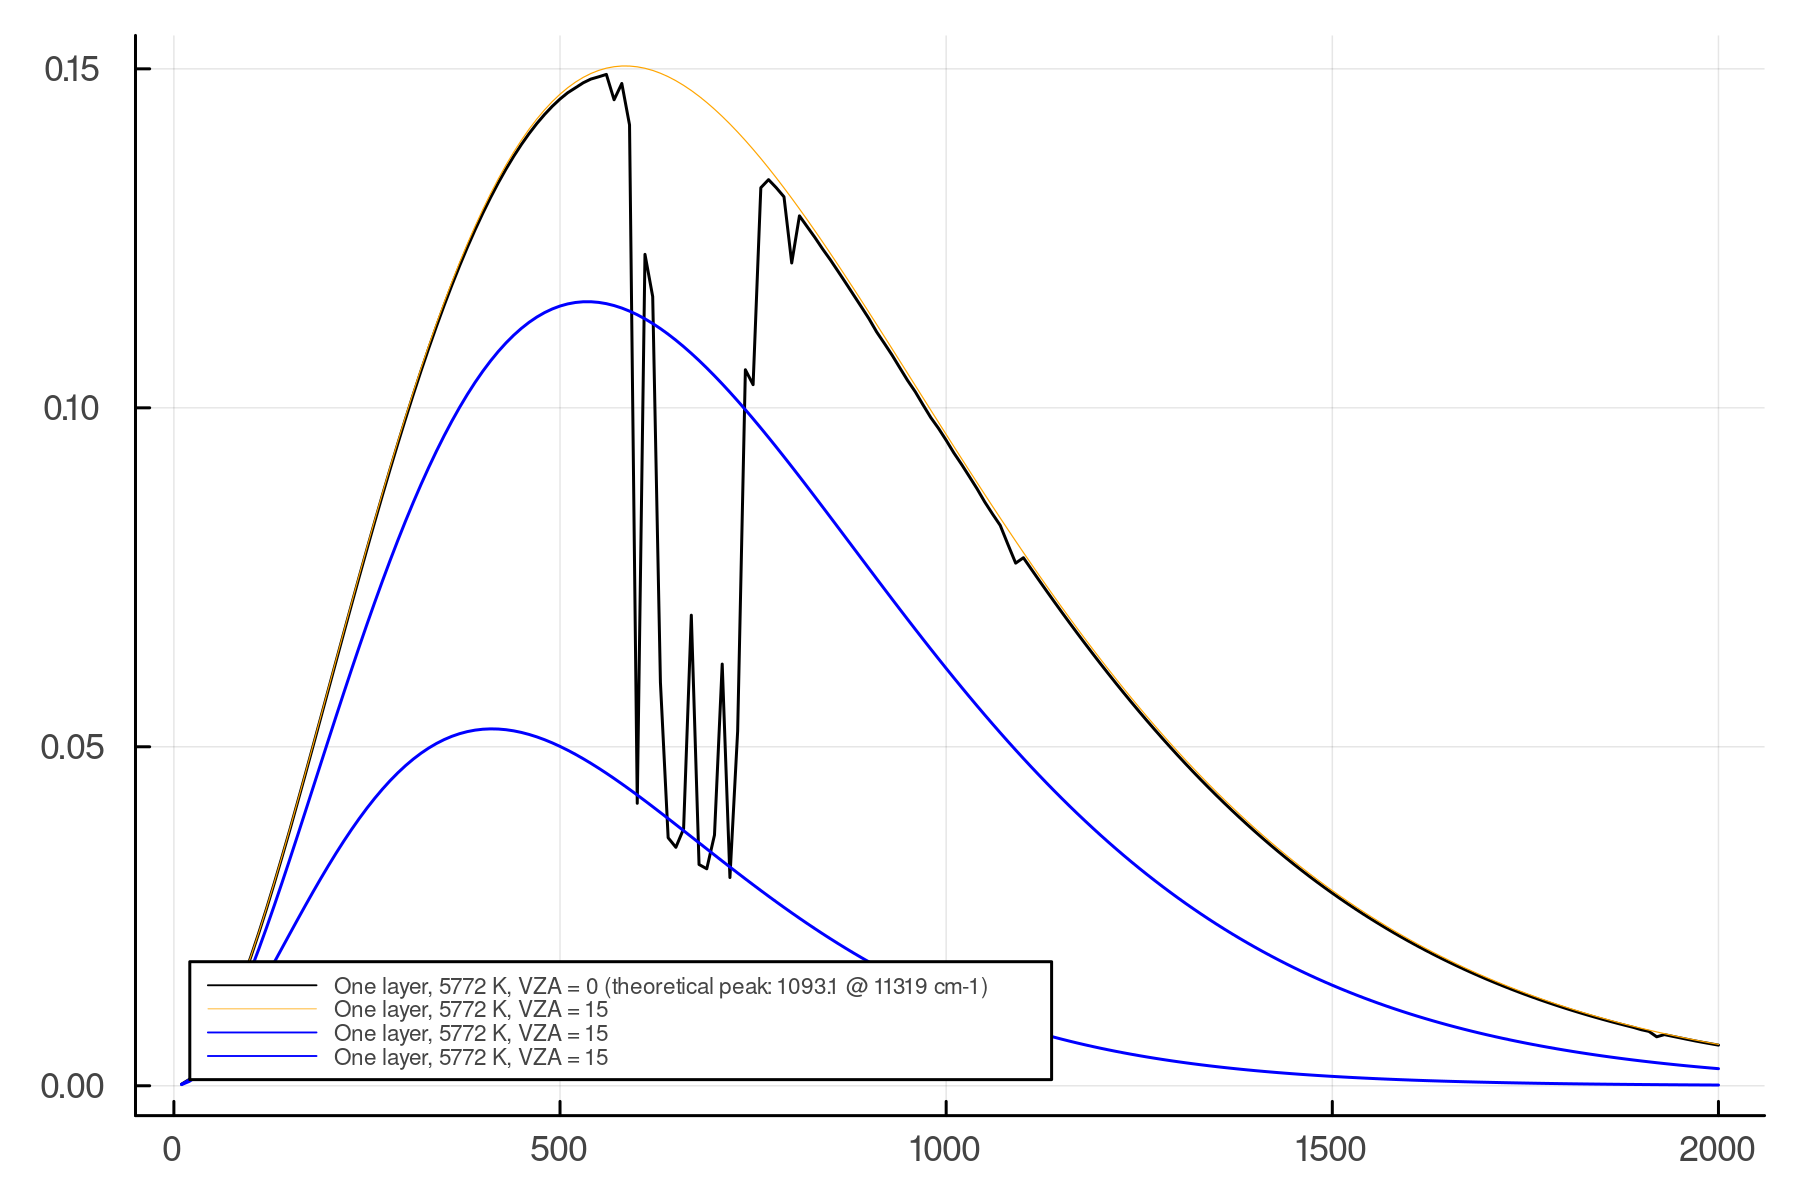

In [6]:
nu = 100:10:2000
nu = 10:10:2000

function planck_spectrum_wn_i(T::Real, ν_grid)
    c1 = 1.1910427 * 10^(-5)    # mW/m²-sr-cm⁻¹
    c2 = 1.4387752              # K⋅cm

    # L(ν, T) = c1⋅ν³/(exp(c2⋅ν/T) - 1)
    radiance = c1 .* (ν_grid.^3) ./ (exp.(c2 * ν_grid / T) .- 1)

    return radiance
end

planck_function = planck_spectrum_wn_i(298, nu) ./ 1000
planck_function_3 = planck_spectrum_wn_i(273, nu) ./ 1000
planck_function_2 = planck_spectrum_wn_i(210, nu) ./ 1000

# p = plot(nu, R_default[1][1,1,:], lw = 1, label = "MERRA2 Profile, VZA = 0", color = "black", dpi = 300)
# plot!(nu, R_default[1][2,1,:], lw = 1, label = "MERRA2 Profile, VZA = 15", color = "blue", dpi = 300)
# plot!(nu, R_default[1][3,1,:], lw = 1, label = "MERRA2 Profile, VZA = 30", color = "red", dpi = 300)
# plot!(nu, R_default[1][4,1,:], lw = 1, label = "MERRA2 Profile, VZA = 45", color = "green", dpi = 300)
# plot!(nu, R_default[1][5,1,:], lw = 1, label = "MERRA2 Profile, VZA = 60", color = "yellow", dpi = 300)
# plot!(nu, R_default[1][6,1,:], lw = 1, label = "MERRA2 Profile, VZA = 75", color = "gray", dpi = 300)

p1 = plot(nu, R_default[1][1,1,:], lw = 1, label = "One layer, 5772 K, VZA = 0 (theoretical peak: 1093.1 @ 11319 cm-1)", color = "black", dpi = 300,legend=:bottomleft, legendfontsize=5)
plot!(nu, planck_function, lw = 0.4, label = "One layer, 5772 K, VZA = 15", color = "orange", dpi = 300)
plot!(nu, planck_function_2, lw = 1, label = "One layer, 5772 K, VZA = 15", color = "blue", dpi = 300)
plot!(nu, planck_function_3, lw = 1, label = "One layer, 5772 K, VZA = 15", color = "blue", dpi = 300)

# plot!(nu, R_default[1][3,1,:], lw = 1, label = "One layer, 5772 K, VZA = 30", color = "orange", dpi = 300)
# plot!(nu, R_default[1][4,1,:], lw = 1, label = "One layer, 5772 K, VZA = 45", color = "green", dpi = 300)
# plot!(nu, R_default[1][5,1,:], lw = 1, label = "One layer, 5772 K, VZA = 60", color = "black", dpi = 300)
# plot!(nu, R_default[2][1,1,:], lw = 1, label = "One layer, 5772 K, VZA = 60", color = "blue", dpi = 300)

For pure scattering ($\bar \omega$ = 1), conservation of flux yields the relation:

$$ \frac{1}{2} \int_{0}^{1}d\mu_v \mu_v \left(I_{BOA}(\lambda, \mu_v) + I_{TOA}(\lambda, \mu_v) \right) = B(\lambda, T_{eff})$$

In [93]:
for i in 1:90
    print(string(i) * ",")
end
println()
for i in 1:90
    print("0,")
end

1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [94]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("conservation_of_flux.yaml");
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
model_output = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385] for band #1

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/atmo_prof.jl:79
┌ Warning: Duplicated knots were deduplicated. Use Interpolations.deduplicate_knots!(knots) explicitly to avoid this warning.
│   k1 = [505.0, 505.0]
└ @ Interpolations /Users/jamesyoon/.julia/packages/Interpolations/USkTk/src/gridded/gridded.jl:77



(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(nquad_radius, λ) = (2500, 502.5)
("Mie", FT, FT2) = ("Mie", Float64, Float64)
aerosol_optics_raw.k = 0.00016862320570057448
((aerosol_optics[i_band])[i_aer]).k = 0.00016862320570057448
FT_dual = Float64
Finished initializing arrays


┌ Info: AOD at band 1 : 5.324471407030899e-6, truncation factor = -8.881784197001252e-16
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/model_from_parameters.jl:178
┌ Info: Processing on: CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (100, 100, 200)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/rt_run.jl:108


Fourier Moment: 0/2
Fourier Moment: 1/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:63


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               78.4s /   2.1%           3.72GiB /  65.0%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
interaction                       3    769ms   46.1%   256ms    552MiB   22.3%   184MiB
  interaction inv2                3   50.4ms    3.0%  16.8ms   45.8MiB    1.8%  15.3MiB
  interaction inv1 bla            3   46.0ms    2.8%  15.3ms   45.8MiB    1.8%  15.3MiB
Absorption Coeff                  2    449ms   26.9%   225ms   1.01GiB   41.8%   518MiB
Creating layers                   3    277ms   16.6%  92.4ms    491MiB   19.8%   164MiB
RT Kernel                      

[0.9998476951563913, 0.9993908270190958, 0.9986295347545738, 0.9975640502598242, 0.9961946980917455, 0.9945218953682733, 0.992546151641322, 0.9902680687415704, 0.9876883405951378, 0.984807753012208, 0.981627183447664, 0.9781476007338057, 0.9743700647852352, 0.9702957262759965, 0.9659258262890683, 0.9612616959383189, 0.9563047559630354, 0.9510565162951535, 0.9455185755993168, 0.9396926207859084, 0.9335804264972017, 0.9271838545667874, 0.9205048534524404, 0.9135454576426009, 0.9063077870366499, 0.898794046299167, 0.8910065241883679, 0.882947592858927, 0.8746197071393957, 0.8660254037844386, 0.8571673007021123, 0.848048096156426, 0.838670567945424, 0.8290375725550417, 0.8191520442889918, 0.8090169943749475, 0.7986355100472928, 0.788010753606722, 0.7771459614569709, 0.766044443118978, 0.754709580222772, 0.7431448254773942, 0.7313537016191705, 0.7193398003386511, 0.7071067811865476, 0.6946583704589973, 0.6819983600624985, 0.6691306063588582, 0.6560590289905073, 0.6427876096865394, 0.6293203

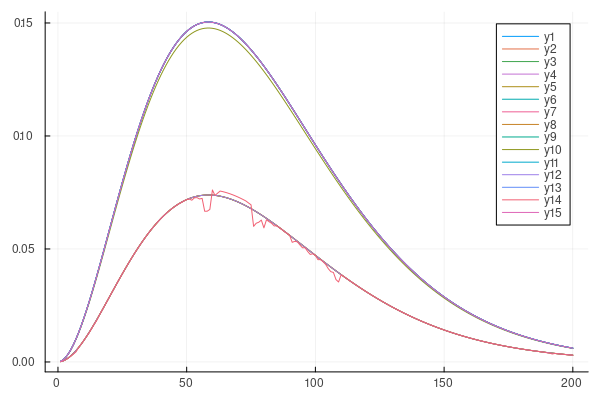

In [95]:
# Test conservation of flux, from Sanghavi and Shporer, 2018 e(Equation 5)

function planck_spectrum_wn_i(T::Real, ν_grid)
    c1 = 1.1910427 * 10^(-5)    # mW/m²-sr-cm⁻¹
    c2 = 1.4387752              # K⋅cm

    # L(ν, T) = c1⋅ν³/(exp(c2⋅ν/T) - 1)
    radiance = c1 .* (ν_grid.^3) ./ (exp.(c2 * ν_grid / T) .- 1)

    return radiance
end

planck_function_eff = planck_spectrum_wn_i(298, nu) ./ 1000

nu = 10:10:2000

toa_intensity = model_output[1];
boa_intensity = model_output[2];

vza = 1:1:89;
cos_vza = cosd.(vza); # the mu_v in Equation 5
print(cos_vza)
left_hand_side = zeros(length(nu));

for i in 1:length(nu)
    for j in 1:length(vza) - 1
        left_hand_side[i] += 1/2 * (abs(cos_vza[j] - cos_vza[j+1]) .* cos_vza[j] .* (toa_intensity[j, 1, i] + boa_intensity[j, 1, i]));
    end
end

plot!(left_hand_side)
# plot!(model_output[1][1,1,:])
plot!(planck_function_eff)

size(model.τ_abs[1]) = (301, 2)


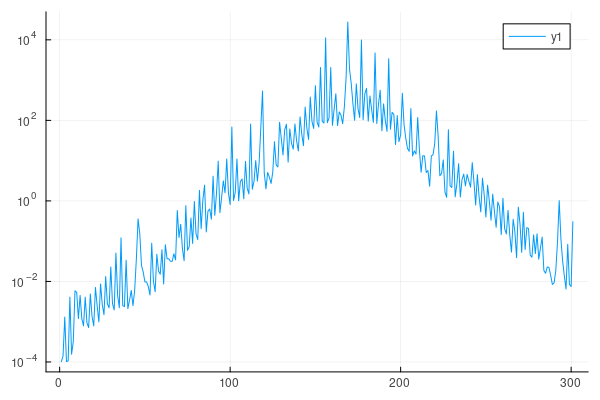

In [6]:
@show size(model.τ_abs[1])
plot(sum(model.τ_abs[1][:,:],dims=2), yscale=:log10)

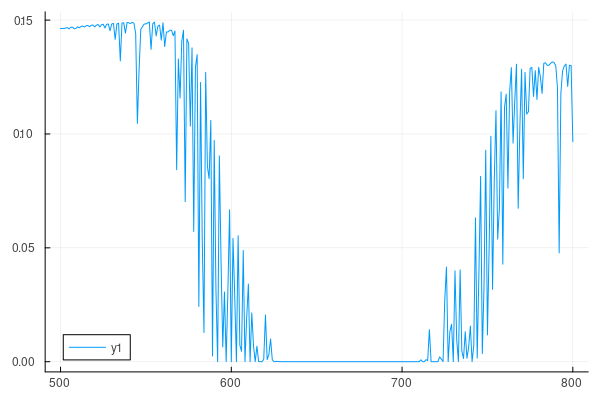

In [7]:
p1 = plot(nu, R_default[1][1,1,:])

In [7]:
# parameters = vSmartMOM.CoreRT.parameters_from_yaml("DefaultParameters-blackbody_radiation.yaml");
parameters = vSmartMOM.CoreRT.parameters_from_yaml("solar_blackbody.yaml");
# parameters.T .= 5772;
# parameters.p = pressures;
# parameters.q = parameters.T .* 0;
# parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
# parameters.absorption_params.vmr["ISOP"] = specific_humidity * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_298 = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.000395] for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
FT_dual = Float64
Finished initializing arrays
Fourier Moment: 0/2
composite_layer.J₀⁺[iμ₀, 1, 10:end] = 

┌ Info: Processing on: Main.vSmartMOM.Architectures.CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (16, 16, 200)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/rt_run.jl:108


[3.036399891220087e-31, 2.5840304876590807e-29, 7.739480101579646e-27, 6.874262263616724e-26, 4.611556389470936e-25, 2.2393912617238792e-23, 1.1561942709954866e-24, 1.9342061448746243e-24, 4.949688827868103e-24, 1.341402064822886e-23, 5.636267579102928e-23, 4.706078052554968e-22, 4.5651254849852854e-21, 1.7622718474800082e-22, 6.333172333493138e-22, 1.1851350970273792e-22, 1.9666294221509422e-23, 1.3843556126678424e-23, 1.5343706206167997e-23, 7.63883917623316e-22, 6.72596003826746e-21, 9.454710242347241e-21, 1.431787474858547e-20, 1.0865663614214007e-18, 1.032995717396421e-19, 2.065747911050298e-20, 6.311742919566349e-20, 1.1095857070641791e-20, 1.2682301021721e-19, 1.1356720324421612e-19, 1.612387276129785e-18, 2.2737612384132183e-19, 7.301731997937056e-18, 3.2118058462106343e-18, 2.1749102644350647e-17, 1.985940836329656e-17, 1.3318164496331543e-15, 2.648423554072077e-16, 4.5299631218687675e-15, 7.124397207267178e-16, 1.3610991474179138e-15, 1.8650465176829214e-14, 1.29780378543825e

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:58
┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:58


In [113]:
# parameters = vSmartMOM.CoreRT.parameters_from_yaml("DefaultParameters-blackbody_radiation.yaml");
parameters = vSmartMOM.CoreRT.parameters_from_yaml("solar_blackbody.yaml");
parameters.T .= 273;
# parameters.p = pressures;
parameters.q = parameters.T .* 0;
# parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
# parameters.absorption_params.vmr["ISOP"] = specific_humidity * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_273 = vSmartMOM.CoreRT.rt_run(model); # Run the model

FT_dual = Float64
Finished initializing arrays
Fourier Moment: 0/2
Fourier Moment: 1/2
Fourier Moment: 2/2
───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               5.79s /   0.3%           40.0MiB /  93.9%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Creating layers                   3   6.28ms   39.3%  2.09ms   12.4MiB   33.1%  4.14MiB
interaction                       3   4.07ms   25.5%  1.36ms   13.9MiB   37.2%  4.65MiB
  interaction inv1 bla            3    779μs    4.9%   260μs   1.16MiB    3.1%   397KiB
  interaction inv2                3    702μs    4.4%   234μs   1.16MiB    3.1%   397KiB
RT Kernel   

┌ Info: Processing on: Main.vSmartMOM.Architectures.CPU()
│ With FT: Float64
│ Source Function Integration: true
│ Dimensions: (16, 16, 191)
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/rt_run.jl:108
┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:58
┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/tools/postprocessing_vza.jl:58


In [ ]:
function planck_spectrum_wn_i(T::Real, ν_grid)
    c1 = 1.1910427 * 10^(-5)    # mW/m²-sr-cm⁻¹
    c2 = 1.4387752              # K⋅cm

    # L(ν, T) = c1⋅ν³/(exp(c2⋅ν/T) - 1)
    radiance = c1 .* (ν_grid.^3) ./ (exp.(c2 * ν_grid / T) .- 1)

    return radiance
end

planck_function_sun = planck_spectrum_wn_i(5772, nu)

In [ ]:
nu = 400:100:50000

# p = plot(nu, R_default[1][1,1,:], lw = 1, label = "MERRA2 Profile, VZA = 0", color = "black", dpi = 300)
# plot!(nu, R_default[1][2,1,:], lw = 1, label = "MERRA2 Profile, VZA = 15", color = "blue", dpi = 300)
# plot!(nu, R_default[1][3,1,:], lw = 1, label = "MERRA2 Profile, VZA = 30", color = "red", dpi = 300)
# plot!(nu, R_default[1][4,1,:], lw = 1, label = "MERRA2 Profile, VZA = 45", color = "green", dpi = 300)
# plot!(nu, R_default[1][5,1,:], lw = 1, label = "MERRA2 Profile, VZA = 60", color = "yellow", dpi = 300)
# plot!(nu, R_default[1][6,1,:], lw = 1, label = "MERRA2 Profile, VZA = 75", color = "gray", dpi = 300)

p1 = plot(nu, R_298[1][1,1,:], lw = 1, label = "One layer, 5772 K, VZA = 0 (theoretical peak: 1093.1 @ 11319 cm-1)", color = "black", dpi = 300,legend=:bottomleft, legendfontsize=5)
plot!(nu, R_298[1][2,1,:], lw = 1, label = "One layer, 5772 K, VZA = 15", color = "blue", dpi = 300)
plot!(nu, R_298[1][3,1,:], lw = 1, label = "One layer, 5772 K, VZA = 30", color = "orange", dpi = 300)
plot!(nu, R_298[1][4,1,:], lw = 1, label = "One layer, 5772 K, VZA = 45", color = "green", dpi = 300)
plot!(nu, R_298[1][5,1,:], lw = 1, label = "One layer, 5772 K, VZA = 60", color = "black", dpi = 300)
plot!(nu, planck_function_sun .* 100, lw = 3, label = "Planck Function @ 5772 K x 100", color = "black", dpi = 300)

# plot!(nu, R_273[1][1,1,:], lw = 1, label = "One layer, 273 K (theoretical peak: 0.11 @ 535 cm-1)", color = "orange", dpi = 300)

# plot!(nu, R_298[1][5,1,:], lw = 2, label = "298 K", color = "orange", dpi = 300)
title!("Solar Spectrum in Wavenumber Space\n GaussQuadFullSphere")
xlabel!("Wavenumber (cm-1)")
ylabel!("Radiance (W m-2 sr-1 cm)")

In [ ]:
wavelength = 1 ./nu / 100 * 1e9

planck_in_wavelength_nm = planck_function_sun .* 1e7 ./ wavelength.^2
solar_spectrum_in_wavelength_nm = R_298[1][1,1,:] .* 1e7 ./ wavelength.^2
solar_spectrum_in_wavelength_nm_2 = R_298[1][2,1,:] .* 1e7 ./ wavelength.^2
solar_spectrum_in_wavelength_nm_3 = R_298[1][3,1,:] .* 1e7 ./ wavelength.^2
solar_spectrum_in_wavelength_nm_4 = R_298[1][4,1,:] .* 1e7 ./ wavelength.^2


In [ ]:
p2 = plot(wavelength, solar_spectrum_in_wavelength_nm, xlimit = [200, 2000], label = "Simulated spectrum, VZA = 0")
plot!(wavelength, solar_spectrum_in_wavelength_nm_2, label = "Simulated spectrum, VZA = 30")
plot!(wavelength, solar_spectrum_in_wavelength_nm_3, label = "Simulated spectrum, VZA = 45")
plot!(wavelength, solar_spectrum_in_wavelength_nm_4, label = "Simulated spectrum, VZA = 60")
plot!(wavelength, planck_in_wavelength_nm .* 200, lw = 2, color = "black", label = "Planck Function (5772 K) x 1000")
ylabel!("Radiance (W m-2 sr-1 nm-1)")
xlabel!("Wavelength (nm)")
title!("Solar Spectrum in wavelength space, \nGaussQuadFullSphere")

In [ ]:
p3 = plot(p1, p2, layout = (2,1))
plot!(size=(1000,1000))
savefig(p3, "solar_spectrum_half_hemisphere.png")

In [ ]:
# nu = (1e7/777):0.015:(1e7/757)
# nu = 890:0.01:910
nu = 10:1:2000

p = plot(nu, R_default[1][:], lw = 1, label = "Simulated spectrum", color = "black", dpi = 300)

planck_function = planck_spectrum_wn_i(298, nu)
plot!(nu, planck_function / 1000, label = "298 K")

planck_function = planck_spectrum_wn_i(273, collect(nu))
plot!(nu, planck_function / 1000, label = "273 K")

ylabel!("Reflectance")
title!("Output from R[1][:]; Current thermal emissions")

p2 = plot(nu, R_default[2][:], lw = 1, label = "Simulated spectrum", color = "black", dpi = 300)
ylabel!("Transmittance")
title!("Output from R[2][:]; Current thermal emissions")
xlabel!("Wavenumber (cm-1)")

p3 = plot(p, p2, layout = (2,1))
savefig(p3, "output.png")
# plot!(nu, R_15ppb_H2O_profile[1][:], lw = 0.5, label = "ISOP with H2O vertical profile, 1e16 molec cm^{-2}")
# plot!(nu, R_15ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 1e16 molec cm^{-2}") 
# plot!(nu, R_3ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 6.3e16 molec cm^{-2}")
# xlims!((892,895))
# ylims!((0.052,0.08))

In [ ]:

xlabel!("Wavenumber (cm^-1)")
ylabel!("ToA Reflectance")
title!("ToA Reflectance | With Current Thermal Emissions")

In [ ]:
# nu = (1e7/777):0.015:(1e7/757)
nu = 890:0.01:910
nu = 10:10:2000

# planck_function = vSmartMOM.CoreRT.planck_spectrum_wn(298, collect(nu))
# plot(nu, planck_function / 1000) 

# planck_function = vSmartMOM.CoreRT.planck_spectrum_wn(273, collect(nu))
# plot!(nu, planck_function / 1000)

# planck_function = vSmartMOM.CoreRT.planck_spectrum_wn(380, collect(nu))
# plot!(nu, planck_function / 1000)

# plot(nu, planck_function)

p = plot(nu, R_default[2][:], lw = 1, label = "Default Parameters", color = "black")
show(p)
# plot!(nu, R_default[1][2,1,:], lw = 1, label = "Default Parameters", color = "black")

# plot!(nu, R_15ppb_H2O_profile[1][:], lw = 0.5, label = "ISOP with H2O vertical profile, 1e16 molec cm^{-2}")
# plot!(nu, R_15ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 1e16 molec cm^{-2}")
# plot!(nu, R_3ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 6.3e16 molec cm^{-2}")
# xlims!((892,895))
# ylims!((0.052,0.08))

xlabel!("Wavenumber (cm^-1)")
ylabel!("ToA Transmittance")
title!("ToA Transmittance | With Current Thermal Emissions")

In [ ]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_ISOP.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_0ppb = vSmartMOM.CoreRT.rt_run(model); # Run the model

####################################
# Make any changes to the YAML file.
parameters = vSmartMOM.CoreRT.parameters_from_yaml("added_ISOP.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
parameters.absorption_params.vmr["ISOP"] = specific_humidity * 1e-7;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_15ppb_H2O_profile = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [ ]:
# Calculate uniform vertical profile that is equivalent in column

current_profile = specific_humidity * 1e-7;
total_column = merra2_profile.vcd_dry .* current_profile;
total_column = sum(total_column)

mean_vmr = total_column / sum(merra2_profile.vcd_dry)

total_column = sum(merra2_profile.vcd_dry .* 3e-9)

In [ ]:
####################################
# Make any changes to the YAML file.
parameters = vSmartMOM.CoreRT.parameters_from_yaml("added_ISOP.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
parameters.absorption_params.vmr["ISOP"] = mean_vmr;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_15ppb_constant_ISOP = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [ ]:
####################################
# Make any changes to the YAML file.
parameters = vSmartMOM.CoreRT.parameters_from_yaml("added_ISOP.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
parameters.absorption_params.vmr["ISOP"] = 3e-9;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_3ppb_constant_ISOP = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [ ]:
nu_min = 890
nu_max = 910
step_size = 0.01
nu = nu_min:step_size:nu_max
# 
plot(nu, R_0ppb[1][:], lw = 0.5, label = "No ISOP", color = "black")
plot!(nu, R_15ppb_H2O_profile[1][:], lw = 0.5, label = "ISOP with H2O vertical profile, 1e16 molec cm^{-2}")
plot!(nu, R_15ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 1e16 molec cm^{-2}")
plot!(nu, R_3ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 6.3e16 molec cm^{-2}")
xlims!((892,895))
ylims!((0.052,0.08))


xlabel!("Wavenumber (cm^-1)")
ylabel!("Reflectance")
title!("ToA Reflectance")

In [ ]:
nu_min = 890
nu_max = 910
step_size = 0.01
nu = nu_min:step_size:nu_max
# 
plot(nu, R_0ppb[1][:], lw = 0.5, label = "No ISOP", color = "black")
plot!(nu, R_15ppb_H2O_profile[1][:], lw = 0.5, label = "ISOP with H2O vertical profile, 1e16 molec cm^{-2}")
plot!(nu, R_15ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 1e16 molec cm^{-2}")
plot!(nu, R_3ppb_constant_ISOP[1][:], lw = 0.5, label = "ISOP with uniform profile, 6.3e16 molec cm^{-2}")
xlims!((892,895))
ylims!((0.052,0.08))


xlabel!("Wavenumber (cm^-1)")
ylabel!("Reflectance")
title!("ToA Reflectance")

In [ ]:
parameters = vSmartMOM.CoreRT.parameters_from_yaml("added_ISOP.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000 * 0.5;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02 * 0.5;
parameters.absorption_params.vmr["ISOP"] = specific_humidity * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_half_humidity = vSmartMOM.CoreRT.rt_run(model); # Run the model

####################################
# Make any changes to the YAML file.
parameters = vSmartMOM.CoreRT.parameters_from_yaml("added_ISOP.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000 * 2;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02 * 2;
parameters.absorption_params.vmr["ISOP"] = specific_humidity * 1e-7;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_double_humidity = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [ ]:
nu_min = 890
nu_max = 910
step_size = 0.01
nu = nu_min:step_size:nu_max
# 
plot(nu, R_15ppb_H2O_profile[1][:], lw = 0.5, label = "ISOP with H2O vertical profile, 1e16 molec cm^{-2}")
plot!(nu, R_half_humidity[1][:], lw = 0.5, label = "x0.5 Humidity")
plot!(nu, R_double_humidity[1][:], lw = 0.5, label = "x2 Humidity")

xlims!((892,895))
ylims!((0.052,0.08))

xlabel!("Wavenumber (cm^-1)")
ylabel!("Reflectance")
title!("ToA Reflectance")

In [ ]:
####################################
# Make any changes to the YAML file.
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_aerosols.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
parameters.absorption_params.vmr["ISOP"] = [0, 1.5e-9];

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_15ppb_interpolation = vSmartMOM.CoreRT.rt_run(model); # Run the model

####################################
# Make any changes to the YAML file.
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_aerosols.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
parameters.absorption_params.vmr["ISOP"] = [0, 3e-9];

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_3ppb_interpolation = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [ ]:
nu = nu_min:step_size:nu_max

plot(nu, R_0ppb[1][:], label = "No ISOP")
plot!(nu, R_15ppb_H2O_profile[1][:], label = "[ISOP]_surf = 1.5 ppb, profile 1")
plot!(nu, R_15ppb_interpolation[1][:], label = "[ISOP]_surf = 1.5 ppb, profile 2 (interp)")
plot!(nu, R_3ppb_interpolation[1][:], label = "[ISOP]_surf = 3 ppb")

# plot!(nu, R_1ppb[1][:], label = "[ISOP]_surf = 1 ppb")
# plot!(nu, R_0[1][:], label = "[ISOP]_surf = 1 ppb")

xlabel!("Wavenumber (cm^-1)")
ylabel!("Radiance?")
title!("Radiances from Isoprene Columns")

## Test how vertical profiles affect the final result!

In [ ]:
dry_air_molar_mass = 28.96
molar_mass_water = 18.02

# Make any changes to the YAML file.
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_aerosols.yaml");
# parameters.absorption_params.molecules = ["O2" "CO2"]
# parameters.T = temperatures;
# parameters.p = pressures;
# parameters.q = specific_humidity;
# parameters.absorption_params.vmr["ISOP"] = 0.;
# parameters.absorption_params.vmr["ISOP"] = 0.;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_default = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Run again
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_aerosols.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
# parameters.absorption_params.molecules = ["O2" "CO2"]
# parameters.absorption_params.vmr["ISOP"] = 0.;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_T_P_q = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Run again
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_aerosols.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = repeat([0], length(temperatures));
# parameters.absorption_params.molecules = ["O2" "CO2"]
# parameters.absorption_params.vmr["ISOP"] = 0.;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_T_P = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Run again
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_aerosols.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
# parameters.absorption_params.molecules = ["O2" "CO2"]
# parameters.absorption_params.vmr["ISOP"] = 0.;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_T_P_q = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Run again
parameters = vSmartMOM.CoreRT.parameters_from_yaml("no_aerosols.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity .* 1000;
# parameters.absorption_params.molecules = ["O2" "CO2"]
parameters.absorption_params.vmr["H2O"] = specific_humidity * 28.96/18.02;
model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
R_T_P_q_with_h2o = vSmartMOM.CoreRT.rt_run(model); # Run the model

In [ ]:
nu = nu_min:step_size:nu_max

plot(nu, R_default[1][:], label = "Default T, P profile")
plot!(nu, R_T_P[1][:], label = "MERRA2 T, P profile")
plot!(nu, R_T_P_q[1][:], label = "MERRA2 T, P, q profile")
plot!(nu, R_T_P_q_with_h2o[1][:], label = "MERRA2 T, P, q profile + H2O")

xlabel!("Wavenumber (cm^-1)")
ylabel!("Radiance?")
title!("Specific Humidity versus VMR H2O", weight = "bold")

In [ ]:
plot(specific_humidity * 1e-7, pressures[2:end], yflip = true, title = "Specific Humidity Profile")
ylabel!("Pressure (hPa)")
xlabel!("Specific Humidity (kg H2O / kg air)")

In [ ]:
pressures[2:end]